# 02. 전처리 & 검증 전략 수립

01단계 EDA에서 알아낸 것을 바탕으로 **"모델에 넣을 수 있는 형태"** 로 데이터를 다듬는다.

### EDA에서 넘어온 과제
| 과제 | 이유 |
|---|---|
| 결측치 처리 | 전 열 4~19% 결측, 완전한 행은 38.9%뿐 → 행 삭제 불가 |
| 범주형 인코딩 | `gender`, `stress_level`, `academic_work_impact` 가 문자열 |
| 검증 틀 구축 | 타깃 불균형 70.9% → 층화(Stratified) 분할 필수 |

### 이 노트북의 결론 미리보기
1. **결측치**: LightGBM에 원본 그대로 넣는 것이 1순위 후보 (03단계에서 실측 비교)
2. **인코딩**: `category` dtype — LightGBM 네이티브 처리가 가장 간단하고 강력
3. **스케일링**: **하지 않는다** — 트리 모델에는 무의미
4. **검증**: `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` 로 고정

## 0. 준비

In [1]:
import sys
sys.path.append('../src')     # src/ 폴더의 우리 모듈을 불러올 수 있게 경로 추가

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

SEED = 42
np.random.seed(SEED)

# 01단계에서 파악한 열 구성을 모듈에 정리해뒀다.
# 노트북마다 복붙하면 한쪽만 고쳤을 때 결과가 어긋나므로 한 곳에서 관리한다.
from preprocess import (load_data, to_category, align_categories,
                        impute_median, add_missing_indicators, add_missing_count,
                        NUM_COLS, CAT_COLS, TARGET)

train, test, sub = load_data('../data/')
y = train[TARGET].values

print(f'train {train.shape} / test {test.shape}')
print(f'수치형 {len(NUM_COLS)}개 / 범주형 {len(CAT_COLS)}개')

train (691369, 14) / test (296302, 13)
수치형 9개 / 범주형 3개


## 1. 결측치 처리 — 3가지 선택지

결측치를 다루는 방법은 크게 셋이다. **어느 게 정답인지는 미리 알 수 없고,
CV 점수로 비교해야 한다.** (실제 비교는 03단계에서 한다)

### 선택지 A — 그대로 두기 (LightGBM 네이티브 처리)

가장 의외지만, **트리 모델에서는 이게 자주 최선이다.**

일반적인 모델(로지스틱 회귀 등)은 `NaN`이 있으면 계산 자체가 안 된다.
하지만 LightGBM 같은 **부스팅 트리**는 다르다. 트리는 "이 변수가 5보다 큰가?"로
데이터를 가르는데, 값이 없는 행에 대해서는 **"왼쪽/오른쪽 중 어디로 보내야
손실이 줄어드는가"를 학습으로 직접 정한다.**

즉 결측을 **버리는 게 아니라 하나의 정보로 취급**한다.
사람이 중앙값으로 억지로 채워 넣는 것보다 나을 때가 많다.

In [2]:
# 아무것도 안 채우고 category 변환만 한다
X_raw = to_category(train[NUM_COLS + CAT_COLS])

print('결측치 그대로 유지:')
print(X_raw.isnull().sum().to_string())
print()
print(f'전체 결측 칸 수: {X_raw.isnull().sum().sum():,} 개')

결측치 그대로 유지:
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224

전체 결측 칸 수: 870,360 개


### 선택지 B — 통계값으로 채우기 (Imputation)

수치형은 **중앙값(median)**, 범주형은 **최빈값(mode)** 으로 채운다.

평균이 아니라 중앙값을 쓰는 이유: 평균은 극단값에 끌려간다.
예를 들어 스크린타임에 15시간짜리가 몇 개 섞여 있으면 평균이 위로 밀리지만,
중앙값은 "가운데 순위 값"이라 흔들리지 않는다.

> #### ⚠️ 데이터 누수(Data Leakage) — 초보자가 가장 많이 하는 실수
>
> ```python
> # ❌ 틀린 방법
> train[col] = train[col].fillna(train[col].median())   # 전체로 중앙값 계산
> ```
>
> 교차검증을 할 때 위처럼 하면, **검증 폴드의 정보가 중앙값을 통해
> 학습에 새어 들어간다.** CV 점수는 좋아 보이는데 리더보드에서 무너진다.
>
> ```python
> # ✅ 올바른 방법
> med = X_tr[col].median()          # 학습 폴드에서만 계산
> X_tr[col] = X_tr[col].fillna(med)
> X_va[col] = X_va[col].fillna(med) # 검증 폴드에는 '적용'만
> ```
>
> `src/preprocess.py`의 `impute_median()`은 계산한 중앙값을 반환하도록 만들어서
> 이 실수를 구조적으로 막는다.

In [3]:
# impute_median()은 (채워진 데이터, 사용한 중앙값, 사용한 최빈값)을 함께 반환한다.
# 반환받은 중앙값을 test에 그대로 적용해야 학습/추론이 일치한다.
X_med, medians, modes = impute_median(to_category(train[NUM_COLS + CAT_COLS]))

print('[ 학습 데이터에서 계산한 대치값 ]')
for c, v in medians.items():
    print(f'  {c:26s} 중앙값 {v}')
for c, v in modes.items():
    print(f'  {c:26s} 최빈값 {v}')

print()
print(f'대치 후 남은 결측: {X_med.isnull().sum().sum()} 개')

[ 학습 데이터에서 계산한 대치값 ]
  age                        중앙값 27.0
  daily_screen_time_hours    중앙값 7.77
  social_media_hours         중앙값 2.31
  gaming_hours               중앙값 1.33
  work_study_hours           중앙값 2.2
  sleep_hours                중앙값 6.8
  notifications_per_day      중앙값 150.0
  app_opens_per_day          중앙값 104.0
  weekend_screen_time        중앙값 9.58
  gender                     최빈값 Male
  stress_level               최빈값 High
  academic_work_impact       최빈값 Yes

대치 후 남은 결측: 0 개


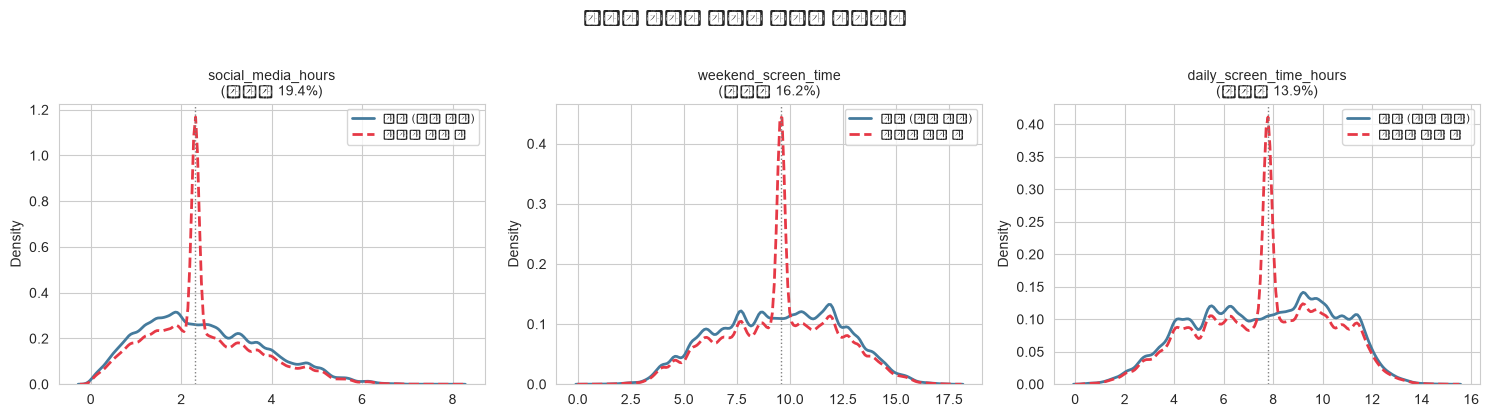

In [4]:
# 대치가 분포를 얼마나 왜곡하는지 눈으로 확인한다.
# 중앙값으로 채우면 그 지점에 막대가 솟는다 = 인위적인 봉우리가 생긴다.
check_cols = ['social_media_hours', 'weekend_screen_time', 'daily_screen_time_hours']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for col, ax in zip(check_cols, axes):
    sns.kdeplot(train[col].dropna(), ax=ax, label='원본 (결측 제외)',
                color='#457b9d', lw=2)
    sns.kdeplot(X_med[col], ax=ax, label='중앙값 대치 후',
                color='#e63946', lw=2, ls='--')
    ax.axvline(medians[col], color='gray', ls=':', lw=1)
    ax.set_title(f'{col}\n(결측률 {train[col].isnull().mean():.1%})', fontsize=10)
    ax.set_xlabel(''); ax.legend(fontsize=8)

plt.suptitle('중앙값 대치가 분포를 어떻게 바꾸는가', y=1.03)
plt.tight_layout(); plt.show()

**해석**: 빨간 점선(대치 후)이 중앙값 근처에서 원본보다 뾰족하게 솟는다.
결측률이 19.4%인 `social_media_hours`에서 특히 심하다.
데이터의 20%를 같은 값 하나로 채웠으니 당연한 결과다.

이렇게 **인위적인 봉우리**가 생기면 모델이 "이 값 근처에 사람이 몰려 있다"고
잘못 학습할 수 있다. 이것이 선택지 A(그대로 두기)가 유리할 수 있는 이유다.

### 선택지 C — 결측 표시 변수 추가 (Missing Indicator)

값을 채우되, **"원래는 비어 있었다"는 사실을 별도 열로 보존**한다.

```python
train['social_media_hours_isna'] = train['social_media_hours'].isnull().astype(int)
```

01단계 EDA에서 이미 검증했다: 결측 여부에 따른 중독률 차이가 최대 0.42%p로
거의 0이었다. → **효과가 없을 가능성이 높다.** 그래도 실측은 03단계에서 한다.

In [5]:
# 결측 표시 변수를 붙이면 열이 12개 -> 24개로 늘어난다
X_ind = add_missing_indicators(X_med, source_df=train)
X_ind = add_missing_count(X_ind, source_df=train)

print(f'열 개수: {X_med.shape[1]} -> {X_ind.shape[1]}')
print()
print('추가된 열:')
print([c for c in X_ind.columns if c.endswith('_isna') or c == 'n_missing'])

열 개수: 12 -> 25

추가된 열:
['age_isna', 'daily_screen_time_hours_isna', 'social_media_hours_isna', 'gaming_hours_isna', 'work_study_hours_isna', 'sleep_hours_isna', 'notifications_per_day_isna', 'app_opens_per_day_isna', 'weekend_screen_time_isna', 'gender_isna', 'stress_level_isna', 'academic_work_impact_isna', 'n_missing']


## 2. 범주형 인코딩

문자열 `'Male'`, `'High'` 같은 값은 모델이 직접 계산할 수 없다. 숫자로 바꿔야 한다.
방법은 세 가지이고, **모델 종류에 따라 유리한 방식이 다르다.**

In [6]:
# ── 방법 1: Label Encoding (각 값에 정수 번호 부여) ──
# Male=0, Female=1, Other=2 ... 처럼 단순히 번호를 매긴다.
# 문제: 모델이 "2 > 1 > 0" 이라는 크기 순서가 있다고 오해할 수 있다.
#       선형 모델에는 치명적이지만, 트리 모델은 '크기'가 아니라 '분기 기준'으로
#       쓰기 때문에 상대적으로 덜 위험하다.
from sklearn.preprocessing import LabelEncoder

demo = train[CAT_COLS].fillna('MISSING')
le_demo = demo.copy()
for c in CAT_COLS:
    le_demo[c] = LabelEncoder().fit_transform(demo[c])

print('[ Label Encoding ]')
print(pd.concat([demo.head(3), le_demo.head(3).add_suffix('_le')], axis=1).to_string())

[ Label Encoding ]
   gender stress_level academic_work_impact  gender_le  stress_level_le  academic_work_impact_le
0    Male       Medium                   No          2                3                        1
1  Female       Medium                   No          0                3                        1
2  Female          Low                  Yes          0                1                        2


In [7]:
# ── 방법 2: One-Hot Encoding (값마다 0/1 열을 하나씩) ──
# 크기 순서 오해가 없다는 게 장점. 대신 열 개수가 늘어난다.
# 카테고리가 수백 개인 변수에 쓰면 열이 폭발한다(차원의 저주).
# 다행히 이 데이터는 카테고리가 2~3개뿐이라 부담이 없다.
oh_demo = pd.get_dummies(demo, columns=CAT_COLS, dtype=int)

print(f'[ One-Hot Encoding ]  {demo.shape[1]}열 -> {oh_demo.shape[1]}열')
print(oh_demo.head(3).to_string())

[ One-Hot Encoding ]  3열 -> 11열
   gender_Female  gender_MISSING  gender_Male  gender_Other  stress_level_High  stress_level_Low  stress_level_MISSING  stress_level_Medium  academic_work_impact_MISSING  academic_work_impact_No  academic_work_impact_Yes
0              0               0            1             0                  0                 0                     0                    1                             0                        1                         0
1              1               0            0             0                  0                 0                     0                    1                             0                        1                         0
2              1               0            0             0                  0                 1                     0                    0                             0                        0                         1


In [8]:
# ── 방법 3: category dtype (LightGBM 네이티브) ── ★ 이번 대회에서 채택
# pandas의 category 타입으로 두면 LightGBM이 알아서 '범주형'으로 인식하고,
# 최적의 그룹 분할(예: {Male, Other} vs {Female})을 스스로 찾는다.
# One-Hot처럼 열이 늘지도 않고, Label Encoding의 순서 오해도 없다.
X_cat = to_category(train[NUM_COLS + CAT_COLS])

print('[ category dtype ]')
print(X_cat[CAT_COLS].dtypes.to_string())
print()
print('gender의 카테고리 목록:', list(X_cat['gender'].cat.categories))
print('내부 저장 코드 (앞 5개):', X_cat['gender'].cat.codes.head().tolist(), '  ※ -1 = 결측')

[ category dtype ]
gender                  category
stress_level            category
academic_work_impact    category

gender의 카테고리 목록: ['Female', 'Male', 'Other']
내부 저장 코드 (앞 5개): [1, 0, 0, 2, 0]   ※ -1 = 결측


> #### ⚠️ train/test 카테고리 정렬 맞추기
>
> train과 test에서 `astype('category')`를 **따로** 하면, 카테고리 순서가 달라져서
> train의 `Male=1`이 test에서는 `Male=0`이 될 수 있다. 모델은 숫자 코드로 학습하므로
> 이러면 예측이 완전히 어긋난다. 눈에 안 띄면서 점수만 갉아먹는 유형의 버그다.
>
> `src/preprocess.py`의 `align_categories()`가 train/test의 카테고리 목록을
> 합집합으로 통일해서 이 문제를 막는다.

In [9]:
# train과 test의 카테고리를 동일한 순서로 맞춘다
tr_c, te_c = align_categories(
    to_category(train[NUM_COLS + CAT_COLS]),
    to_category(test[NUM_COLS + CAT_COLS]),
)

print('카테고리 정렬 확인:')
for c in CAT_COLS:
    same = list(tr_c[c].cat.categories) == list(te_c[c].cat.categories)
    print(f'  {c:24s} train={list(tr_c[c].cat.categories)}  일치={same}')

카테고리 정렬 확인:
  gender                   train=['Female', 'Male', 'Other']  일치=True
  stress_level             train=['High', 'Low', 'Medium']  일치=True
  academic_work_impact     train=['No', 'Yes']  일치=True


## 3. 스케일링 — 이번엔 하지 않는다

입문 강의에서는 보통 `StandardScaler`로 스케일을 맞추라고 배운다.
하지만 **이번 대회에서는 필요 없다.** 이유를 정확히 알아두면 앞으로 시간을 아낄 수 있다.

| 모델 종류 | 스케일링 필요? | 이유 |
|---|---|---|
| 선형 회귀 / 로지스틱 회귀 | ✅ 필수 | 계수 크기가 변수 스케일에 직접 좌우됨 |
| SVM, KNN, 신경망 | ✅ 필수 | 거리 계산·경사하강이 스케일에 민감 |
| **결정트리 / 랜덤포레스트** | ❌ 불필요 | 분기 기준이 "값의 순서"에만 의존 |
| **LightGBM / XGBoost / CatBoost** | ❌ 불필요 | 위와 동일 |

**핵심**: 트리는 `daily_screen_time > 7.5` 같은 **부등호 비교**만 한다.
모든 값에 100을 곱해도 순서가 그대로면 분기 지점도 그대로다.
`notifications_per_day`(20~250)와 `sleep_hours`(4.5~9)의 스케일이 12배 차이 나도
트리는 전혀 신경 쓰지 않는다.

> 05단계 앙상블에서 **로지스틱 회귀를 블렌딩에 섞는다면** 그때는 스케일링이 필요하다.

In [10]:
# 스케일 차이가 실제로 얼마나 큰지 확인해두자 (트리에는 상관없지만 기록용)
scale_info = pd.DataFrame({
    '최솟값': train[NUM_COLS].min(),
    '최댓값': train[NUM_COLS].max(),
    '범위': train[NUM_COLS].max() - train[NUM_COLS].min(),
    '표준편차': train[NUM_COLS].std(),
}).round(2).sort_values('범위', ascending=False)
scale_info

,최솟값,최댓값,범위,표준편차
notifications_per_day,20.00,250.00,230.00,65.92
app_opens_per_day,15.00,180.00,165.00,48.09
weekend_screen_time,0.51,17.56,17.05,2.86
age,18.00,35.00,17.00,5.15
daily_screen_time_hours,0.50,15.00,14.50,2.72
social_media_hours,0.00,8.00,8.00,1.32
work_study_hours,0.00,6.00,6.00,1.26
sleep_hours,4.50,9.00,4.50,1.23
gaming_hours,0.00,4.00,4.00,0.93


## 4. 검증 전략 — Stratified 5-Fold

**이 노트북에서 가장 중요한 부분이다.** 앞으로 모든 실험은 여기서 정한
분할 방식을 그대로 써야 점수를 서로 비교할 수 있다.

### 왜 K-Fold인가
데이터를 한 번만 8:2로 나눠 평가하면, **운 좋게 쉬운 검증셋을 뽑았을 수도 있다.**
K-Fold는 데이터를 K조각으로 나눠 **K번 학습·검증하고 평균**을 내므로
"운"의 영향을 줄인다.

### 왜 Stratified(층화)인가
타깃이 70.9% : 29.1%로 치우쳐 있다. 그냥 무작위로 나누면 어떤 폴드는 양성이 68%,
다른 폴드는 74%가 되어 점수가 들쭉날쭉해진다. 층화 분할은 **각 폴드의 타깃 비율을
원본과 똑같이 유지**한다.

### 왜 random_state를 고정하는가
매번 다르게 섞이면 "점수가 오른 게 내 피처 덕분인지, 분할이 달라져서인지"
구분할 수 없다. `SEED = 42`로 고정해 **공정한 비교**를 보장한다.

In [11]:
from cv import get_folds, N_SPLITS

# 폴드 분할을 한 번 만들어 재사용한다.
# 실험마다 새로 나누면 분할이 달라져 비교가 무의미해진다.
folds = get_folds(train, y, n_splits=5, seed=SEED)

print(f'{len(folds)}개 폴드 생성 완료')
print()
rows = []
for i, (tr_idx, va_idx) in enumerate(folds, 1):
    rows.append({
        '폴드': i,
        '학습 행': len(tr_idx),
        '검증 행': len(va_idx),
        '학습 양성비율': y[tr_idx].mean(),
        '검증 양성비율': y[va_idx].mean(),
    })
fold_df = pd.DataFrame(rows)
fold_df['전체와의 차이'] = (fold_df['검증 양성비율'] - y.mean()).abs()
fold_df.round(6)

5개 폴드 생성 완료



,폴드,학습 행,검증 행,학습 양성비율,검증 양성비율,전체와의 차이
0,1,553095,138274,0.709424,0.709425,0.000000
1,2,553095,138274,0.709424,0.709425,0.000000
2,3,553095,138274,0.709424,0.709425,0.000000
3,4,553095,138274,0.709424,0.709425,0.000000
4,5,553096,138273,0.709425,0.709423,0.000002


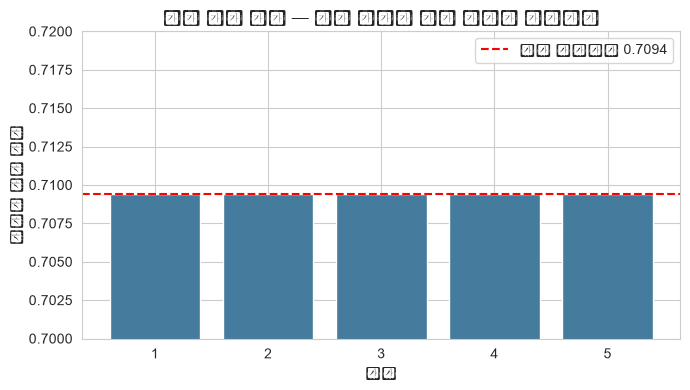

폴드 간 양성비율 최대 편차: 0.000002
-> 0에 매우 가까우면 층화가 제대로 된 것이다.


In [12]:
# 층화가 실제로 작동했는지 그림으로 확인한다.
# 막대가 빨간 선(전체 평균)에 딱 붙어 있어야 정상이다.
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(fold_df['폴드'].astype(str), fold_df['검증 양성비율'], color='#457b9d')
ax.axhline(y.mean(), color='red', ls='--', lw=1.5, label=f'전체 양성비율 {y.mean():.4f}')
ax.set_ylim(0.70, 0.72)
ax.set_xlabel('폴드'); ax.set_ylabel('검증셋 양성 비율')
ax.set_title('층화 분할 검증 — 모든 폴드의 타깃 비율이 동일한가')
ax.legend()
plt.tight_layout(); plt.show()

print(f'폴드 간 양성비율 최대 편차: {fold_df["전체와의 차이"].max():.6f}')
print('-> 0에 매우 가까우면 층화가 제대로 된 것이다.')

## 5. 전처리 파이프라인 정리

지금까지 정한 것을 `src/preprocess.py`와 `src/cv.py`에 함수로 정리해뒀다.
03단계부터는 아래 3줄이면 준비가 끝난다.

```python
import sys; sys.path.append('../src')
from preprocess import load_data, align_categories, to_category, NUM_COLS, CAT_COLS, TARGET
from cv import get_folds, run_cv, ExperimentLog
```

### 모듈에 들어 있는 함수
| 함수 | 역할 |
|---|---|
| `load_data()` | train / test / submission 한 번에 로드 |
| `to_category()` | 문자열 → category dtype |
| `align_categories()` | train/test 카테고리 순서 통일 (버그 방지) |
| `impute_median()` | 중앙값 대치 + 사용한 값 반환 (누수 방지) |
| `add_missing_indicators()` | 결측 표시 변수 생성 |
| `build_features()` | 파생변수 생성 (04단계에서 사용) |
| `get_folds()` | Stratified 5-Fold 분할 (SEED 고정) |
| `run_cv()` | CV 루프 + OOF/테스트 예측 반환 |
| `ExperimentLog` | 실험 점수 누적 기록 |

In [13]:
# 03단계에서 쓸 데이터를 최종 점검한다
X_train_final, X_test_final = align_categories(
    to_category(train[NUM_COLS + CAT_COLS]),
    to_category(test[NUM_COLS + CAT_COLS]),
)

print('=== 03단계 투입 준비 완료 ===')
print(f'X_train : {X_train_final.shape}')
print(f'X_test  : {X_test_final.shape}')
print(f'y       : {y.shape}, 양성비율 {y.mean():.4f}')
print()
print('dtype 구성:')
print(X_train_final.dtypes.value_counts().to_string())
print()
# 학습 전 마지막 확인: train과 test의 열이 정확히 같은 순서인가
assert list(X_train_final.columns) == list(X_test_final.columns), '열 순서 불일치!'
print('✅ train/test 열 구성 일치 확인')

=== 03단계 투입 준비 완료 ===
X_train : (691369, 12)
X_test  : (296302, 12)
y       : (691369,), 양성비율 0.7094

dtype 구성:
float64     9
category    1
category    1
category    1

✅ train/test 열 구성 일치 확인


---
## 📌 02단계 요약

### 결정한 것
| 항목 | 결정 | 근거 |
|---|---|---|
| 결측치 | **원본 유지**를 1순위로, 대치안과 CV 비교 | 대치 시 인위적 봉우리 발생 확인 |
| 인코딩 | **`category` dtype** (LightGBM 네이티브) | 열 증가 없음 + 순서 오해 없음 |
| 스케일링 | **하지 않음** | 트리 모델은 값의 순서만 사용 |
| 검증 | **StratifiedKFold(5, shuffle, seed=42)** | 불균형 데이터 + 재현성 확보 |

### 방지한 함정 2가지
1. **데이터 누수** — 대치값은 학습 폴드에서만 계산하도록 함수 설계
2. **카테고리 순서 불일치** — `align_categories()`로 train/test 통일

### 다음 단계 (03_baseline_lgbm)
- [ ] LightGBM 베이스라인 CV AUC 측정
- [ ] 결측 처리 전략 A/B/C 실측 비교
- [ ] 피처 중요도 확인 → 04단계 파생변수 설계의 근거로 사용